# **T1**

**Crie um modelo Decision Tree para classificar a qualidade dos vinhos e exiba a árvore gerada.**

**Dados:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Input variables (based on physicochemical tests):

* fixed acidity

* volatile acidity

* citric acid

* residual sugar

* chlorides

* free sulfur dioxide

* total sulfur dioxide

* density

* pH

* sulphates

* alcohol

Output variable (based on sensory data):

* quality (score between 0 and 10)

In [152]:
# Download do conjunto de dados
!gdown 1ttOCd6VQH85CfdRvGXqt4UI3pjF73vJl --quiet

Sugestões de etapas:


1.   Ler os dados
2.   Criação do Label (1 se maior que 5, 0 caso contrário)
3.   Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)
4.   Divisão dos dados em treino e teste
5.   Pré-processamento
6.   Treinamento do modelo DecisionTree
7.   Validação do modelo e exibição de uma parte da árvore



# **Referências**

**Árvore de decisão:** https://didatica.tech/como-funciona-o-algoritmo-arvore-de-decisao/

**Aprendizado de máquina: Árvore de Decisão Indutiva:** https://www.cin.ufpe.br/~pacm/SI/ArvoreDecisaoIndutiva.pdf

**DecisionTree scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**Comparação diferentes normalizadores:** https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

###Resolução T1###

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import graphviz
from IPython.display import Image

###Ler os dados###


In [154]:
df = pd.read_csv("winequality-red.csv", sep=';')
display(df)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Criação do Label (1 se maior que 5, 0 caso contrário)


In [155]:
df['label'] = (df['quality'] > 5).astype(int)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)


In [156]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  label                 1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [158]:
df['label'].value_counts()

,count
label,
1,855
0,744


In [159]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.534709
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.498950
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


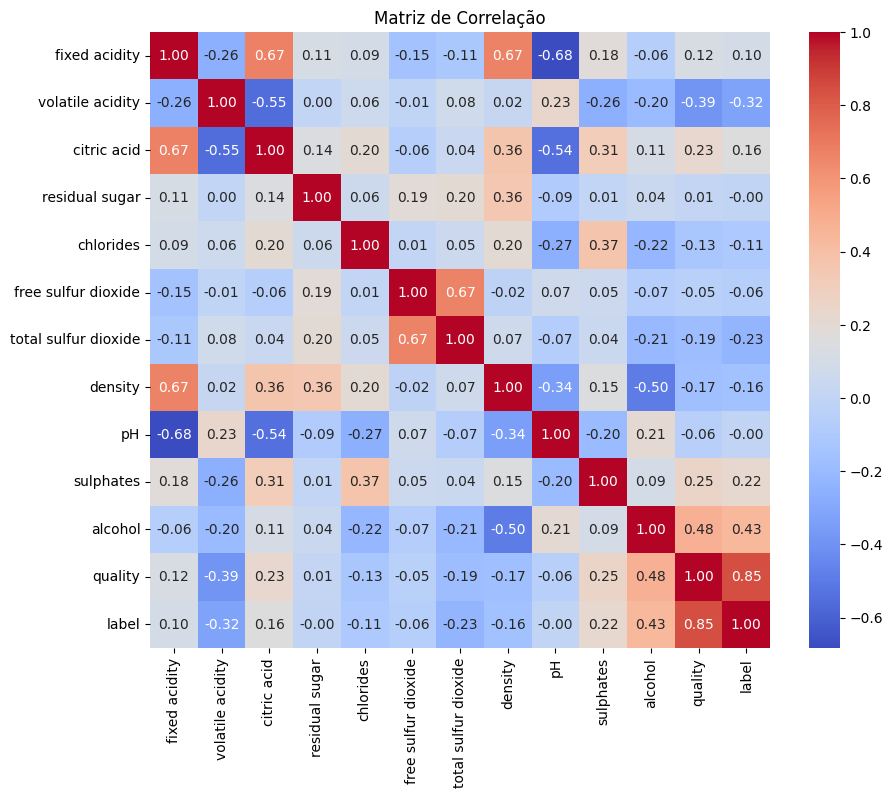

In [160]:
# Matriz de correlação
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

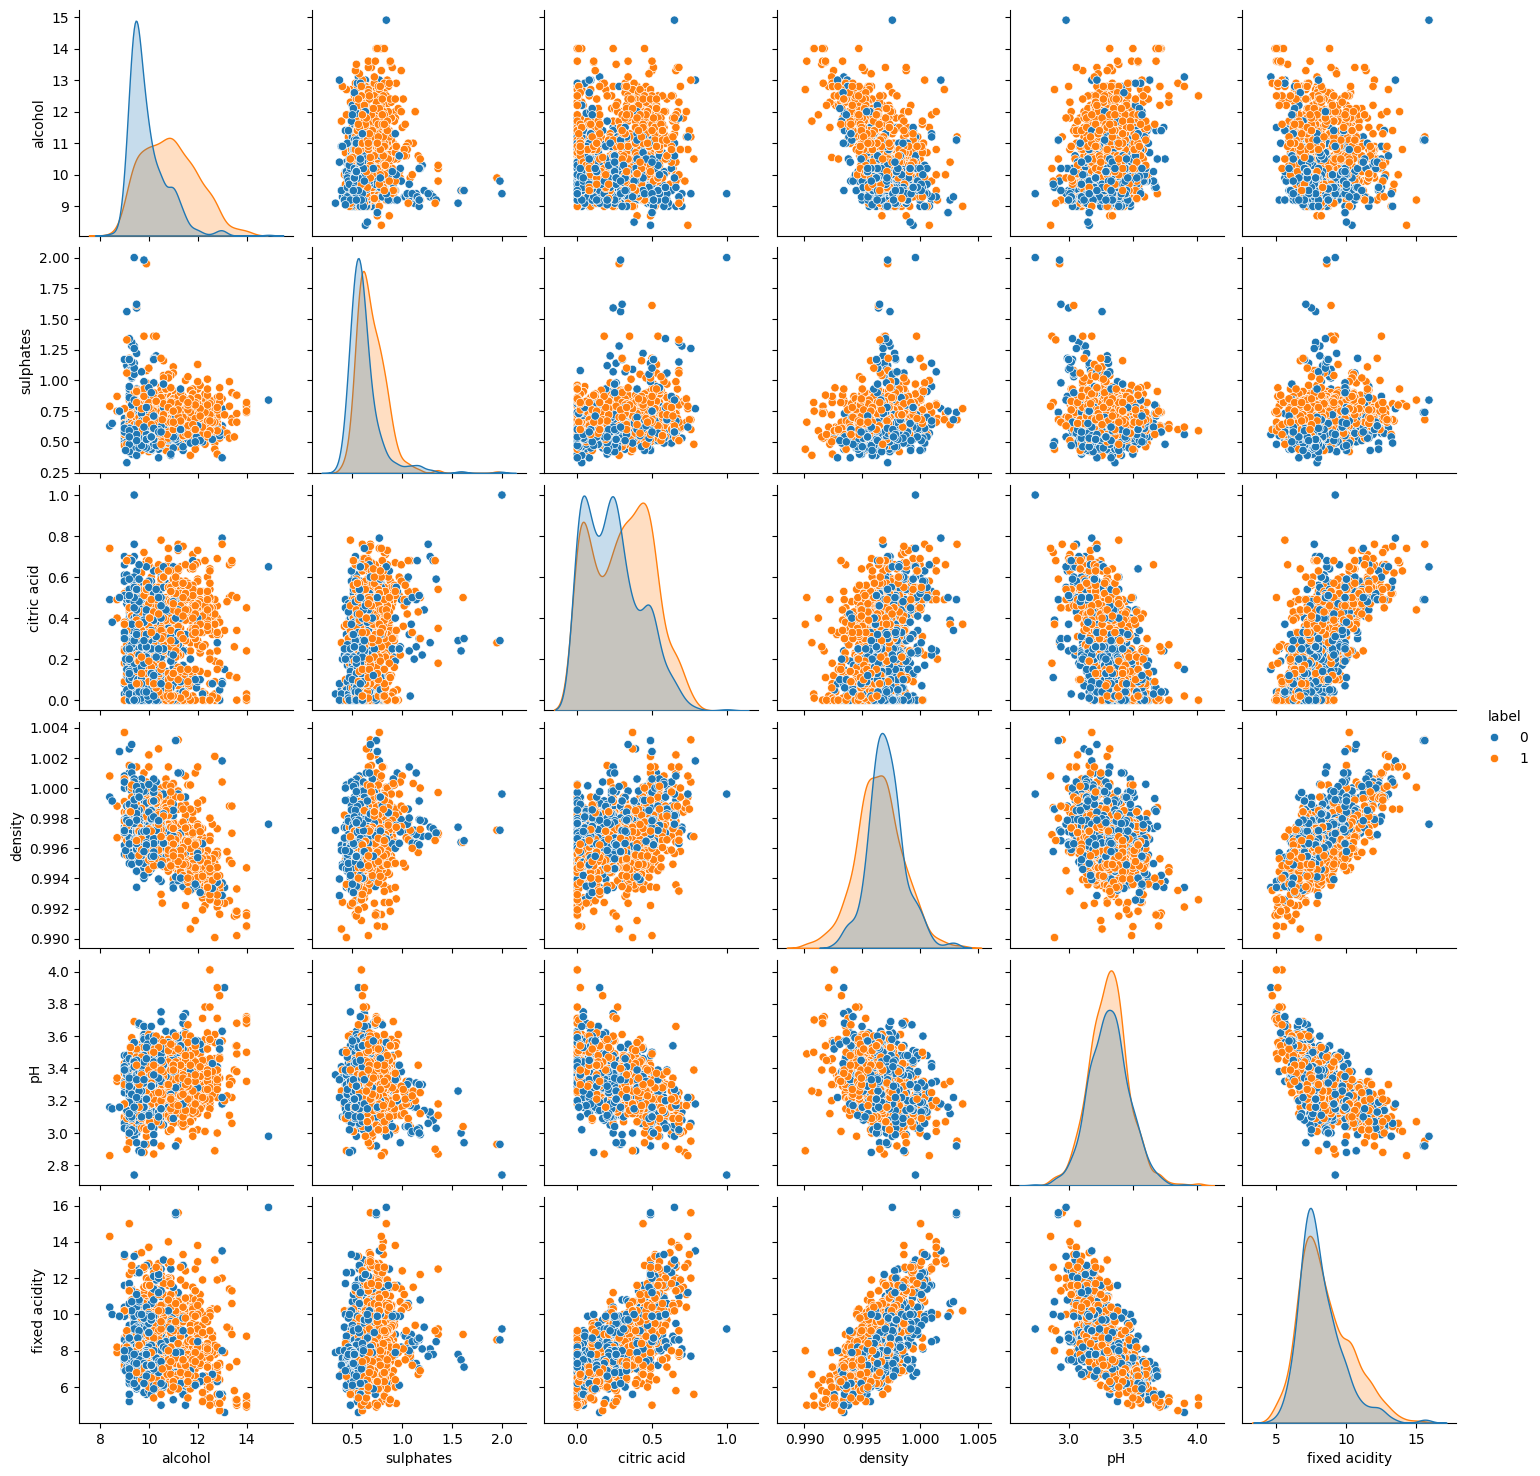

In [161]:
# Pairplot com um subset de variáveis
sns.pairplot(df[['alcohol', 'sulphates', 'citric acid', 'density', 'pH', 'fixed acidity', 'label']], hue='label')
plt.show()

Divisão dos dados em treino e teste


In [162]:
X = df.drop(['quality', 'label'], axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Pré-processamento


In [163]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Treinamento do modelo DecisionTree


In [183]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Validação do modelo e exibição de uma parte da árvore

              precision    recall  f1-score   support

           0       0.68      0.67      0.67       141
           1       0.74      0.75      0.75       179

    accuracy                           0.72       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.72      0.72      0.72       320



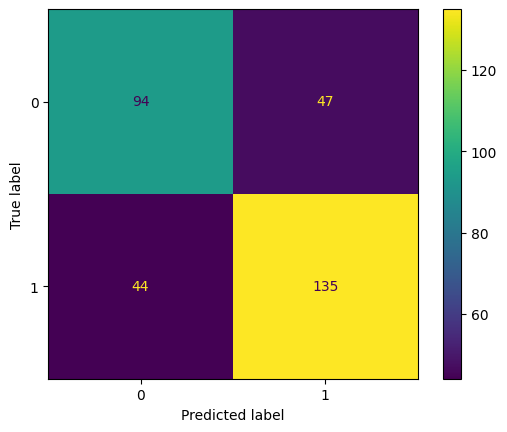

In [184]:
y_pred = clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [166]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.68      0.67      0.67       141
           1       0.74      0.75      0.75       179

    accuracy                           0.72       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.72      0.72      0.72       320



In [167]:
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X.columns,
    class_names=['Baixa Qualidade', 'Alta Qualidade'],
    filled=True,
    rounded=True,
    special_characters=True
)

In [168]:
graph = graphviz.Source(dot_data)

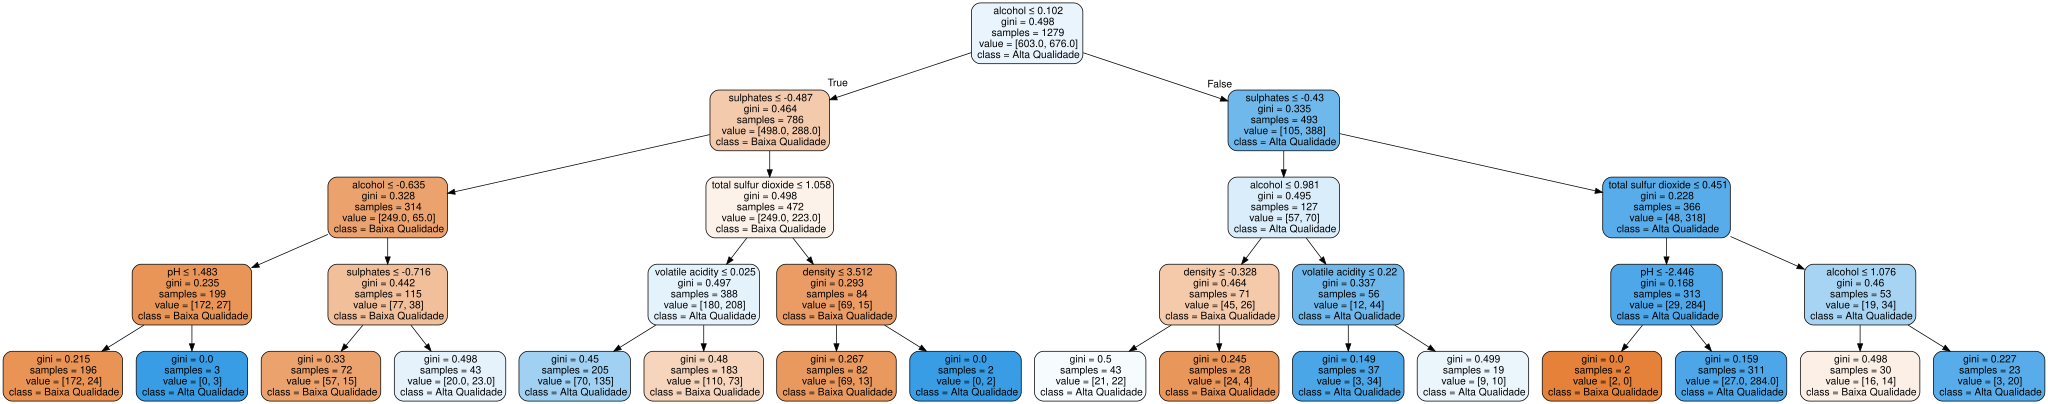

In [169]:
graph.render("decision_tree_wine", format="png", cleanup=False)
graph

###GridSeachCV


In [170]:
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [171]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=25), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)
best_clf = grid_search.best_estimator_

In [172]:
best_clf

DecisionTreeClassifier(random_state=25)

In [173]:
y_pred = best_clf.predict(X_test_scaled)
y_proba = best_clf.predict_proba(X_test_scaled)[:, 1]
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       141
           1       0.76      0.74      0.75       179

    accuracy                           0.73       320
   macro avg       0.72      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320



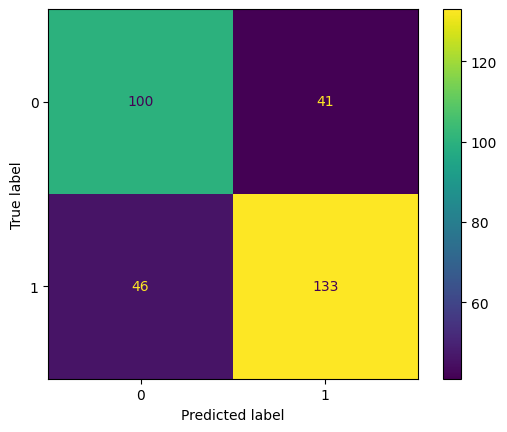

In [174]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

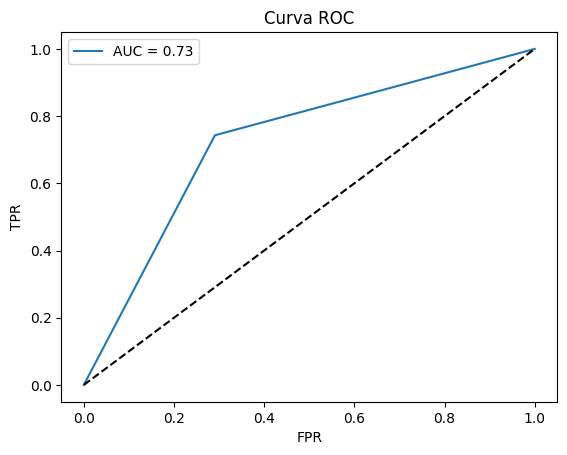

In [175]:
# AUC e curva ROC
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Normalizando os dados por Minimos e Maximos

In [176]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
norm.fit(X_train)

X_train_norm = norm.transform(X_train)
X_test_norm = norm.transform(X_test)

###Treinamento do modelo DecisionTree###

In [177]:
classifier = DecisionTreeClassifier(criterion='entropy', random_state=25)
classifier.fit(X_train_norm, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=25)

###Validação do modelo e exibição de uma parte da árvore

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       141
           1       0.78      0.81      0.79       179

    accuracy                           0.77       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.77      0.76       320



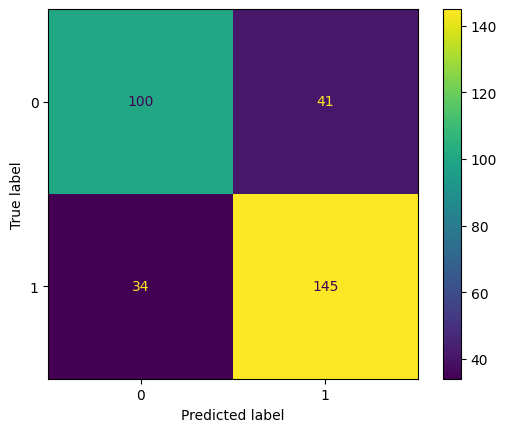

In [178]:
y_pred = classifier.predict(X_test_norm)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

In [179]:
y_train.value_counts()

,count
label,
1,676
0,603


In [180]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       141
           1       0.78      0.81      0.79       179

    accuracy                           0.77       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.77      0.76       320

